### Setup Data Train-Test 
    Before modeling step, first step is setup data for training and testing

Data traning will take 80% of all data

In [ ]:
# library
import glob
import random

# Read data from normal & SCD in directory
normalList = glob.glob("Grayscale/Timeseries-Normal//*")
scdList = glob.glob("Grayscale/Timeseries-SCD//*")

# setup train of size
trainSize = 0.6 # 80% of data will use for training

# calculate train size normal and SCD data
scdSize = int(len(scdList)*trainSize)
normalSize = int(len(normalList)*trainSize)

# generate random data for train and test in SCD
scdTrain = random.sample(scdList, k=round(scdSize))
scdTest = list(set(scdList) - set(scdTrain))

# generate random data for train and test in normal
normalTrain = random.sample(normalList, k=round(normalSize))
normalTest = list(set(normalList) - set(normalTrain))

# Show data for training
print('--- Training Dataset ----')
print(scdTrain)
print(normalTrain)

print()

# Show data for testing
print('--- Testing Dataset ----')
print(scdTest)
print(normalTest)

--- Training Dataset ----
['Grayscale/Timeseries-SCD/37', 'Grayscale/Timeseries-SCD/38', 'Grayscale/Timeseries-SCD/33', 'Grayscale/Timeseries-SCD/47', 'Grayscale/Timeseries-SCD/48', 'Grayscale/Timeseries-SCD/35', 'Grayscale/Timeseries-SCD/44', 'Grayscale/Timeseries-SCD/30', 'Grayscale/Timeseries-SCD/50', 'Grayscale/Timeseries-SCD/32', 'Grayscale/Timeseries-SCD/34', 'Grayscale/Timeseries-SCD/46']
['Grayscale/Timeseries-Normal/18177', 'Grayscale/Timeseries-Normal/19090', 'Grayscale/Timeseries-Normal/16273', 'Grayscale/Timeseries-Normal/19093', 'Grayscale/Timeseries-Normal/16420', 'Grayscale/Timeseries-Normal/16265', 'Grayscale/Timeseries-Normal/16483', 'Grayscale/Timeseries-Normal/16786', 'Grayscale/Timeseries-Normal/16272', 'Grayscale/Timeseries-Normal/16795']

--- Testing Dataset ----
['Grayscale/Timeseries-SCD/31', 'Grayscale/Timeseries-SCD/41', 'Grayscale/Timeseries-SCD/52', 'Grayscale/Timeseries-SCD/51', 'Grayscale/Timeseries-SCD/39', 'Grayscale/Timeseries-SCD/36', 'Grayscale/Timese

In [ ]:
# library
import shutil

# function for change directory of dst
def changeDirectory(data, directory, new):
    start = len(directory)
    values = []
    for i in range(0,len(data)):
        values.append(new+data[i][start:len(data[i])])
    return(values)


# get new directory 
scdTrainDst = changeDirectory(scdTrain, 'Grayscale/Timeseries-SCD/', 'Data/Timeseries Modeling/Train/SCD/')
scdTestDst = changeDirectory(scdTest, 'Grayscale/Timeseries-SCD/', 'Data/Timeseries Modeling/Test/SCD/')
normalTrainDst = changeDirectory(normalTrain, 'Grayscale/Timeseries-Normal/', 'Data/Timeseries Modeling/Train/Normal/')
normalTestDst = changeDirectory(normalTest, 'Grayscale/Timeseries-Normal/', 'Data/Timeseries Modeling/Test/Normal/')

# copy the folder & files
def copyData(dtSrc, dtDst):
    for i in range(1, len(dtSrc)):
        shutil.copytree(dtSrc[i], dtDst[i])

copyData(scdTrain, scdTrainDst)
copyData(scdTest, scdTestDst)
copyData(normalTrain, normalTrainDst)
copyData(normalTest, normalTestDst)

In [ ]:
# Show current data in Train and Test
import glob

print('--- Training Dataset ---')
listTrain = glob.glob("Data/Timeseries Modeling/Train/SCD/*")
for v in listTrain:
    print(v)
listTrain = glob.glob("Data/Timeseries Modeling/Train/Normal/*")
for v in listTrain:
    print(v)

print()

print('--- Testing Dataset ---')
listTest = glob.glob("Data/Timeseries Modeling/Test/SCD/*")
for v in listTest:
    print(v)
listTest = glob.glob("Data/Timeseries Modeling/Test/Normal/*")
for v in listTest:
    print(v)

--- Training Dataset ---
Data/Timeseries Modeling/Train/SCD/50
Data/Timeseries Modeling/Train/SCD/32
Data/Timeseries Modeling/Train/SCD/35
Data/Timeseries Modeling/Train/SCD/34
Data/Timeseries Modeling/Train/SCD/33
Data/Timeseries Modeling/Train/SCD/44
Data/Timeseries Modeling/Train/SCD/38
Data/Timeseries Modeling/Train/SCD/30
Data/Timeseries Modeling/Train/SCD/46
Data/Timeseries Modeling/Train/SCD/48
Data/Timeseries Modeling/Train/SCD/47
Data/Timeseries Modeling/Train/Normal/16795
Data/Timeseries Modeling/Train/Normal/16420
Data/Timeseries Modeling/Train/Normal/19093
Data/Timeseries Modeling/Train/Normal/16265
Data/Timeseries Modeling/Train/Normal/16786
Data/Timeseries Modeling/Train/Normal/16273
Data/Timeseries Modeling/Train/Normal/16483
Data/Timeseries Modeling/Train/Normal/19090
Data/Timeseries Modeling/Train/Normal/16272

--- Testing Dataset ---
Data/Timeseries Modeling/Test/SCD/51
Data/Timeseries Modeling/Test/SCD/45
Data/Timeseries Modeling/Test/SCD/43
Data/Timeseries Modeling/

### We have done to roadmap the train and testing data. It makes more easier for buidling Classication Model

## Modeling step

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import seaborn as sn

from skimage import io
import cv2
import os

import numpy as np
import pandas as pd

import glob



### Read Dataset

In [3]:
labels = ['Normal', 'SCD']

def get_data(data_dir, sample):
    df = [] 
    for label in labels: 
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        folder = glob.glob(path+'/*')
        for v in folder: # looping folder of the data
            print('Get data   ', v)
            files = glob.glob(v+'/*') # get all files png
            
            # take number and sort
            if(sample == 'Train'):
                if(label == 'Normal'):
                    val = [int(x[44:-4]) for x in files]                
                else: # SCD
                    val = [int(x[38:-4]) for x in files]                
            else: # Test sample
                if(label == 'Normal'):
                    val = [int(x[43:-4]) for x in files]                
                else: # SCD
                    val = [int(x[37:-4]) for x in files] 
            
            term = pd.DataFrame(val)
            term['dict'] = files
            term.columns = ['val', 'dict']

            data = []
            for path in term.sort_values(by='val')['dict']: # looping png file asc
                try:
                    img_arr = cv2.imread(path)[...,::-1] #convert BGR to RGB format
                    resized_arr = cv2.resize(img_arr, (400, 800)) # Reshaping images to preferred size
                    data.append([resized_arr, class_num])
                except Exception as e:
                    print(e)

            data = np.array(data)
            datas = np.stack((data[0][0], data[1][0]))
            
            # save the datas into df
            df.append([datas, class_num])
    return(df)

In [4]:
# Read the data train and test
train = get_data('Data/Timeseries Modeling/Train', 'Train')
train = np.array(train)

In [5]:
# read test
test = get_data('Data/Timeseries Modeling/Test', 'Test')
test = np.array(test)

In [7]:
import seaborn as sns

# Visualize train data
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("SCD")
sns.set_style('darkgrid')
sns.countplot(l)

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


ValueError: ignored

/Users/mobiledevmac24/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:ylabel='count'>

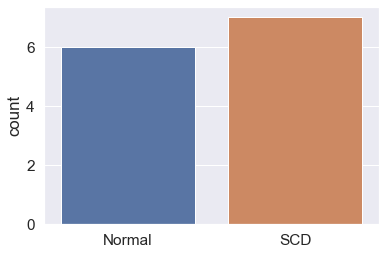

In [ ]:
# Visualize test data
l = []
for i in test:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("SCD")
sns.set_style('darkgrid')
sns.countplot(l)

In [ ]:
# check the image data
plt.figure(figsize = (400,800))
plt.imshow(train[10][0][0])
plt.title(labels[train[10][1]])

Text(0.5, 1.0, 'SCD')

In [ ]:
# check size of data
test[0][0].shape

(2, 800, 400, 3)

## Pre-pare Dataset

In [ ]:
# Pre pare the dataset
x_train = []
y_train = []
x_test = []
y_test = []

# Label 0 is normal
# Label 1 is SCD
for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

print(x_train)
print(y_train)

[array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        ...,

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
       

In [ ]:
# Normalize the data
x_train = np.array(x_train) / 255
x_test = np.array(x_test) / 255

In [ ]:
# change the target into numpy values
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
# Check shape of data training
print('Train: ', x_train.shape)
print('Test: ', x_test.shape)

Train:  (20, 2, 800, 400, 3)
Test:  (13, 2, 800, 400, 3)


## Create CNN LSTM Image Classification Model

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , Input, GlobalAveragePooling2D, TimeDistributed, MaxPool2D , Flatten , Dropout, LSTM, Bidirectional, Lambda, Reshape, regularization
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam

from sklearn.metrics import classification_report,confusion_matrix, f1_score

import tensorflow as tf

#### Function or Method use for modeling process

In [ ]:
# Show report precision and prediction
from sklearn import metrics
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt


def evalution(y_test, prediction_class):
    tn, fp, fn, tp = confusion_matrix(y_test, prediction_class).ravel()

    accuracy = round((tp+tn)/(tp+tn+fn+fp), 3)
    sensitivity = round(tp/(tp+fn), 3)
    specificity = round(tn/(tn+fp), 3)
    precision = round(tp/(fp+tp), 3)
    f1 = round(metrics.f1_score(y_test, prediction_class), 3)

    print('Evaluation Result')
    print('-----------------')
    print('Accuracy:    ', accuracy)
    print('Sensitivity: ', sensitivity)
    print('Specificity: ', specificity)
    print('Precision:   ', precision)
    print('F1 Score:    ', f1)
    
    print('\n\n')
    
    array = confusion_matrix(y_test, prediction_class)

    df_cm = pd.DataFrame(array, columns=['Normal', 'SCD'])
    df_cm.index = ['Normal', 'SCD']

    plt.figure(figsize=(10,7))
    plt.title('Plotting Confusion Matrix Result')
    sn.set(font_scale=1.4) # for label size
    sn.heatmap(df_cm, annot=True, annot_kws={"size": 16}, cmap="YlGnBu") # font size

    plt.show()

In [ ]:
print(y_train)
print(y_test)

[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 1 1 1 1 1 1 1]


In [ ]:
# import tensorflow as tf
# time = 10
# n_classes = 2
# height,width,color_channels = img_size,img_size,3
# batch_size = 16

# # Create CNN-LSTM Model
# def get_conv_inception(input_batch):

#     # 64
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu') )(input_batch)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu') )(conv_model)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPool2D(pool_size=(2,2), padding='SAME',strides=(2,2)))(conv_model)
    
#     # 128
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu') )(conv_model)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu') )(conv_model)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPool2D(pool_size=(2,2), padding='SAME',strides=(2,2)))(conv_model)

#     # 256
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu') )(conv_model)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu') )(conv_model)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPool2D(pool_size=(2,2), padding='SAME',strides=(2,2)))(conv_model)
    
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.5))(conv_model)
#     conv_model = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(conv_model)
#     return conv_model


# def create_network():
#     input_batch = tf.keras.layers.Input(shape = (time,height,width,color_channels))

#     image_features = get_conv_inception(input_batch)
# #     lstm_network = tf.keras.layers.LSTM(256, return_sequences=True,dropout=0.5,recurrent_dropout=0.5)(image_features)
#     lstm_network = tf.keras.layers.Dense(2048,activation='relu')(image_features)
#     lstm_network = tf.keras.layers.Dense(2048,activation='relu')(lstm_network)
#     lstm_network = tf.keras.layers.Dense(2,activation='softmax')(lstm_network)

#     full_network = tf.keras.Model([input_batch],lstm_network)
#     full_network.summary()
#     return full_network


In [ ]:
# model = Sequential()

# #  Conv2D...
# model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'), input_shape=(2, 256, 256, 3))) # time, ori wight, ori height, channel color
# model.add(TimeDistributed(MaxPool2D()))

# model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu')))
# model.add(TimeDistributed(MaxPool2D()))

# model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
# model.add(TimeDistributed(MaxPool2D()))

# model.add(TimeDistributed(Dropout(.4)))
# model.add(TimeDistributed(Flatten()))

# model.add(LSTM(128, return_sequences=False))

# model.add(Dense(128, activation='softmax'))
# model.add(Dense(2, activation='softmax'))

# model.summary()


In [ ]:
# x_train_new = np.reshape(x_train, (20, 2, 244, 244*3))
# x_test_new = np.reshape(x_test, (13, 2, 244, 244*3))

x_train_new = x_train.reshape(20, 800, 244, 3)
x_test_new = x_test.reshape(13, 800, 44, 3)

print(x_train_new.shape)
print(x_test_new.shape)

ValueError: cannot reshape array of size 7144320 into shape (20,488,488,3)

In [ ]:
# Data augmentation
# Input data training into keras preprocessing for image classification
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

datagen.fit(x_train_new)

/Users/mobiledevmac24/opt/anaconda3/lib/python3.9/site-packages/keras/preprocessing/image.py:1874: UserWarning: Expected input to be images (as Numpy array) following the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3 or 4 channels on axis 3. However, it was passed an array with shape (20, 244, 244, 6) (6 channels).
  warnings.warn('Expected input to be images (as Numpy array) '


In [ ]:
model = Sequential()

model.add(Conv2D(32,3,padding="same", activation="relu", input_shape=(244, 244, 6)))
model.add(MaxPool2D())

model.add(Conv2D(32, 3, padding="same", activation="relu"))
model.add(MaxPool2D())

model.add(Conv2D(64, 3, padding="same", activation="relu"))
model.add(MaxPool2D())
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(2, activation="softmax"))

model.summary()

2022-07-07 11:53:30.229842: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 244, 244, 32)      1760      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 122, 122, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 122, 122, 32)      9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 61, 61, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 64)       0

### Training dataset

In [ ]:
# Start training
opt = Adam(lr=0.000001)
model.compile(optimizer = opt, 
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

# Training Model process and save the result into history 
history = model.fit(x_train_new, y_train, epochs = 100, validation_data = (x_test_new, y_test))

Epoch 1/100


/Users/mobiledevmac24/opt/anaconda3/lib/python3.9/site-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)
/Users/mobiledevmac24/opt/anaconda3/lib/python3.9/site-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


1/1 [==============================] - 1s 1s/step - loss: 0.6697 - accuracy: 0.5000 - val_loss: 0.7034 - val_accuracy: 0.4615
Epoch 2/100
1/1 [==============================] - 1s 610ms/step - loss: 0.7100 - accuracy: 0.4500 - val_loss: 0.7015 - val_accuracy: 0.4615
Epoch 3/100
1/1 [==============================] - 1s 590ms/step - loss: 0.7529 - accuracy: 0.3500 - val_loss: 0.6998 - val_accuracy: 0.4615
Epoch 4/100
1/1 [==============================] - 1s 586ms/step - loss: 0.7295 - accuracy: 0.4500 - val_loss: 0.6981 - val_accuracy: 0.4615
Epoch 5/100
1/1 [==============================] - 1s 591ms/step - loss: 0.7621 - accuracy: 0.5000 - val_loss: 0.6967 - val_accuracy: 0.4615
Epoch 6/100
1/1 [==============================] - 1s 576ms/step - loss: 0.6912 - accuracy: 0.5500 - val_loss: 0.6956 - val_accuracy: 0.3846
Epoch 7/100
1/1 [==============================] - 1s 602ms/step - loss: 0.7336 - accuracy: 0.4000 - val_loss: 0.6948 - val_accuracy: 0.5385
Epoch 8/100
1/1 [===========

Epoch 59/100
1/1 [==============================] - 1s 595ms/step - loss: 0.7196 - accuracy: 0.3500 - val_loss: 0.6885 - val_accuracy: 0.5385
Epoch 60/100
1/1 [==============================] - 1s 581ms/step - loss: 0.7071 - accuracy: 0.5000 - val_loss: 0.6884 - val_accuracy: 0.5385
Epoch 61/100
1/1 [==============================] - 1s 580ms/step - loss: 0.6592 - accuracy: 0.7000 - val_loss: 0.6882 - val_accuracy: 0.5385
Epoch 62/100
1/1 [==============================] - 1s 592ms/step - loss: 0.6228 - accuracy: 0.7000 - val_loss: 0.6881 - val_accuracy: 0.5385
Epoch 63/100
1/1 [==============================] - 1s 587ms/step - loss: 0.7948 - accuracy: 0.5000 - val_loss: 0.6881 - val_accuracy: 0.5385
Epoch 64/100
1/1 [==============================] - 1s 587ms/step - loss: 0.7555 - accuracy: 0.3000 - val_loss: 0.6880 - val_accuracy: 0.5385
Epoch 65/100
1/1 [==============================] - 1s 587ms/step - loss: 0.7243 - accuracy: 0.5500 - val_loss: 0.6879 - val_accuracy: 0.5385
Epoch 

In [ ]:
# Show the result of tranning and Testing set Result
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Testing Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Testing Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Testing Loss')
plt.legend(loc='upper right')
plt.title('Training and Testing Loss')
plt.show()

NameError: name 'history' is not defined

1/1 [==============================] - 0s 160ms/step
Evaluation Result
-----------------
Accuracy:     0.538
Sensitivity:  1.0
Specificity:  0.0
Precision:    0.538
F1 Score:     0.7





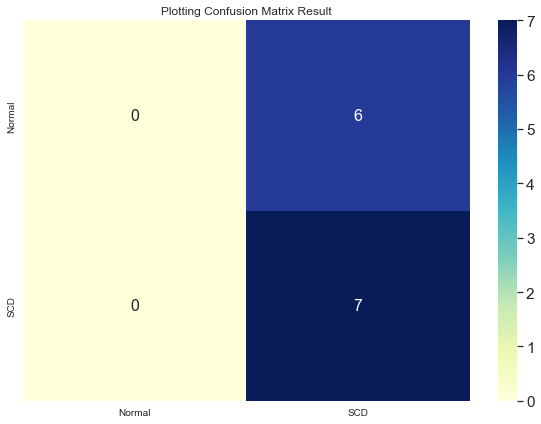

In [ ]:
def getClass(value):
    if(value[1] >= value[0]):
        return(1)
    else:
        return(0)
    
# predict test data
predictions = model.predict(x_test_new)

# Get class of prediction
prediction_class = []
for val in predictions[:,]:
    prediction_class.append(getClass(val))
evalution(y_test, prediction_class)

1/1 [==============================] - 0s 162ms/step
Evaluation Result
-----------------
Accuracy:     0.55
Sensitivity:  1.0
Specificity:  0.0
Precision:    0.55
F1 Score:     0.71





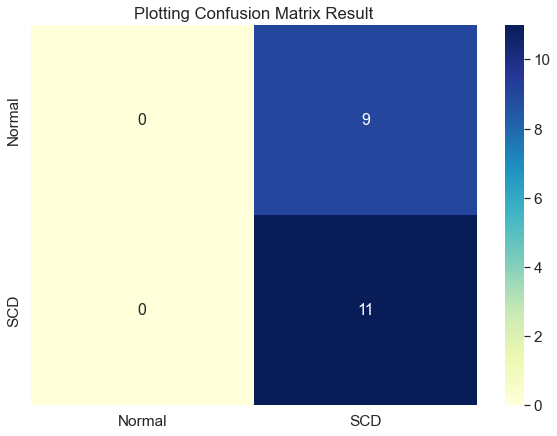

In [ ]:
# predict train data
predictions = model.predict(x_train_new)

# Get class of prediction
prediction_class = []
for val in predictions[:,]:
    prediction_class.append(getClass(val))
evalution(y_train, prediction_class)

In [ ]:
# model.save("Model/CNN_model_v1")
# model.save('Model/CNN_LSTM_model_v1/')

INFO:tensorflow:Assets written to: Model/CNN_model_v1/assets


INFO:tensorflow:Assets written to: Model/CNN_model_v1/assets


## Predicted Testing Dataset

In [ ]:
# Save model 
# model.save("Model/CNN_LSTM_model_v1")
# model2.save("Model/CNN_LSTM_model_v2")




INFO:tensorflow:Assets written to: Model/CNN_LSTM_model_v2/assets


INFO:tensorflow:Assets written to: Model/CNN_LSTM_model_v2/assets


## Predicted Model

In [ ]:
from tensorflow import keras
model = keras.models.load_model('Model/CNN_model_v1/')
model.summary()

Model: "sequential_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 400, 800, 32)      896       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 200, 400, 32)     0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 200, 400, 32)      9248      
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 100, 200, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 100, 200, 64)      18496     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 50, 100, 64)    

1/1 [==============================] - 0s 497ms/step
Evaluation Result
-----------------
Accuracy:     1.0
Sensitivity:  1.0
Specificity:  1.0
Precision:    1.0
F1 Score:     1.0





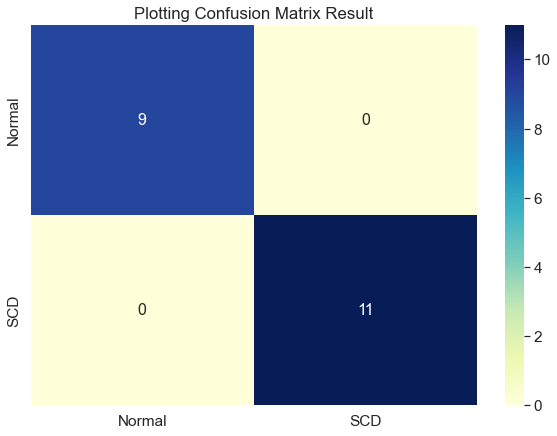

In [ ]:
# predict test data
predictions = model.predict(x_train)

# Get class of prediction
prediction_class = []
for val in predictions[:,]:
    prediction_class.append(getClass(val))
evalution(y_train, prediction_class)

1/1 [==============================] - 0s 440ms/step
Evaluation Result
-----------------
Accuracy:     0.846
Sensitivity:  0.857
Specificity:  0.833
Precision:    0.857
F1 Score:     0.857





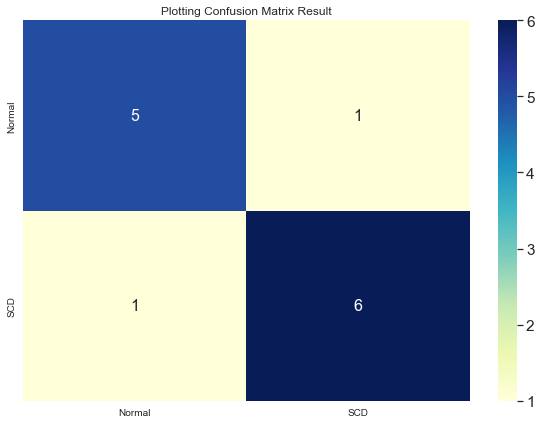

In [ ]:
# predict test data
predictions = model.predict(x_test)

# Get class of prediction
prediction_class = []
for val in predictions[:,]:
    prediction_class.append(getClass(val))
evalution(y_test, prediction_class)